In [2]:
# General imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy import integrate
from copy import deepcopy

# cloelib imports
from cloelib.cosmology.camb_cosmology import CAMBBackground, CAMBLinearPerturbations, CAMBNonLinearPerturbations
from cloelib.cosmology.HMcode2020Emu_cosmology import HMemuLinearPerturbations, HMemuNonLinearPerturbations
from cloelib.observables.photo import ShearTracer, PositionsTracer
from cloelib.summary_statistics.angular_two_point import AngularTwoPoint
from cloelib.summary_statistics.angular_correlation_function_wigner import AngularCorrelationFunctionWigner

import euclidlib as el

# Plot style
import seaborn as sns
sns.set_theme(style="ticks")
sns.set_palette(sns.color_palette("Paired"))

plt.rc('xtick',labelsize=20)
plt.rc('ytick',labelsize=20)
plt.rc('font',size=20)
plt.rc('axes', titlesize=25)
plt.rc('axes', labelsize=20)
plt.rc('lines', linewidth=3)
plt.rc('lines', markersize=6)
plt.rc('legend', fontsize=14)

/Users/s2265800/miniforge3/envs/mgl_ccl_cloe_env/lib/python3.11/site-packages/HMcode2020Emu
Loading linear emulator...


Linear emulator loaded in memory.
Loading nonlinear emulator...
Non-linear emulator loaded in memory.
Loading linear emulator...
Baryonic boost emulator loaded in memory.
Loading sigma8 emulator...
Linear emulator loaded in memory.


In [3]:
# Path to the FITS file
fits_file = '/Users/s2265800/Desktop/GitHub/playground_th1/tutorials/RR2/nz_v1.4_shear.fits'

# Read FITS file using astropy
from astropy.io import fits

# Open the FITS file
with fits.open(fits_file) as hdul:
    # hdul is a HDUList object (Header Data Unit List)
    # Print information about the file structure
    print(f"Number of HDUs: {len(hdul)}")
    print("\nHDU information:")
    hdul.info()
    
    # Access the primary HDU (first extension)
    primary_hdu = hdul[0]
    print(f"\nPrimary HDU shape: {primary_hdu.data.shape if primary_hdu.data is not None else 'No data'}")
    print(f"Primary HDU header keys: {list(primary_hdu.header.keys())[:10]}...")  # Show first 10 keys
    
    # Access data from primary HDU
    if primary_hdu.data is not None:
        primary_data = primary_hdu.data
        print(f"\nPrimary data type: {type(primary_data)}")
        print(f"Primary data shape: {primary_data.shape}")
    
    # Access other extensions (if any)
    for i, hdu in enumerate(hdul):
        print(f"\nHDU {i}:")
        print(f"  Name: {hdu.name}")
        print(f"  Type: {type(hdu)}")
        if hasattr(hdu, 'data') and hdu.data is not None:
            print(f"  Data shape: {hdu.data.shape}")
            print(f"  Data dtype: {hdu.data.dtype}")
        if hasattr(hdu, 'header'):
            print(f"  Header cards: {len(hdu.header)}")

Number of HDUs: 2

HDU information:
Filename: /Users/s2265800/Desktop/GitHub/playground_th1/tutorials/RR2/nz_v1.4_shear.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       6   ()      
  1  BIN_INFO      1 BinTableHDU     18   6R x 3C   [J, E, 3000E]   

Primary HDU shape: No data
Primary HDU header keys: ['SIMPLE', 'BITPIX', 'NAXIS', 'EXTEND', 'COMMENT', 'COMMENT']...

HDU 0:
  Name: PRIMARY
  Type: <class 'astropy.io.fits.hdu.image.PrimaryHDU'>
  Header cards: 6

HDU 1:
  Name: BIN_INFO
  Type: <class 'astropy.io.fits.hdu.table.BinTableHDU'>
  Data shape: (6,)
  Data dtype: (numpy.record, [('BIN_ID', '>i4'), ('MEAN_REDSHIFT', '>f4'), ('N_Z', '>f4', (3000,))])
  Header cards: 18


In [4]:
# Alternative: Simple way to read FITS file
from astropy.io import fits

# Method 1: Read entire file
hdul = fits.open(fits_file)

# Method 2: Read specific HDU (extension)
# hdul[0] = primary HDU
# hdul[1] = first extension (often a binary table)
primary_data = hdul[0].data
primary_header = hdul[0].header

# Method 3: If it's a binary table (common for redshift distributions)
# Access as a Table object (more convenient)
from astropy.table import Table
table = Table.read(fits_file)

# Or read a specific extension as a table
# table = Table.read(fits_file, hdu=1)  # Read extension 1 as a table

# Display the table
print("Table columns:", table.colnames)
print("\nFirst few rows:")
print(table[:5])  # Show first 5 rows

# Access specific columns
# column_data = table['column_name']

# Don't forget to close the file when done
hdul.close()


Table columns: ['BIN_ID', 'MEAN_REDSHIFT', 'N_Z']

First few rows:
BIN_ID MEAN_REDSHIFT    N_Z    
------ ------------- ----------
     1     0.3544592 0.0 .. 0.0
     2    0.56020826 0.0 .. 0.0
     3    0.82188094 0.0 .. 0.0
     4     1.0670109 0.0 .. 0.0
     5     1.3448076 0.0 .. 0.0


In [5]:
z_nz, nz = el.photo.redshift_distributions('../RR2/nz_v1.4_shear.fits')
cls_wl = el.photo.angular_power_spectra('../RR2/spectra_WL.fits')
mixmats = el.photo.mixing_matrices('../RR2/mixmats_WL.fits')
cov_file = '../RR2/cov_TOT_3x2pt_2D.npz'
full_cov = np.load(cov_file)['arr_0']

In [6]:
full_cov.shape


(2496, 2496)

In [7]:
zs = np.linspace(1e-4, 3, 100)

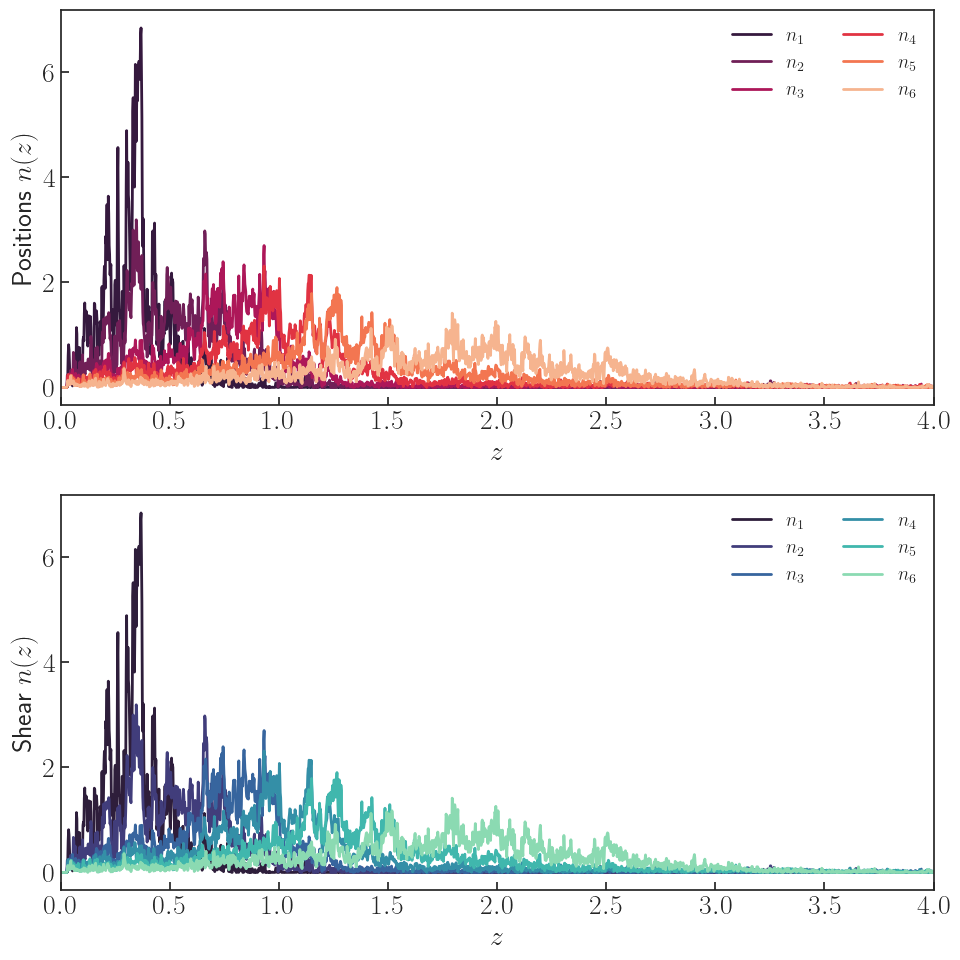

In [8]:
# Function to normalize dndz
def normalize_dndz(nz_example, z_nz):
    normalized = {}
    for key in nz_example:
        normalized[key] = nz_example[key] / integrate.trapezoid(nz_example[key], z_nz)
    return normalized

# Normalize both dndz_pos and dndz_she
dndz_pos_norm = normalize_dndz(nz, z_nz)
dndz_she_norm = normalize_dndz(nz, z_nz)

# Function to resample the normalized dndz
def resample_dndz(nz_example, z_nz, myz):
    my_dndz = np.vstack(list(nz_example.values()))
    my_dndz_norm = np.zeros([len(nz_example), len(myz)])
    for i in range(len(nz_example)):
        my_dndz_norm[i, :] = np.interp(myz, z_nz, my_dndz[i, :])
    return my_dndz_norm

# Resampling the normalized dndz with 100 values
my_dndz_pos_norm = resample_dndz(dndz_pos_norm, z_nz, zs)
my_dndz_she_norm = resample_dndz(dndz_she_norm, z_nz, zs)

# Plotting dndz
fig, axs = plt.subplots(2, 1, figsize=(10, 10))

# Customize tick parameters for both axes
for ax in axs.flatten():
    ax.tick_params(axis='both', which='both', direction='in')

# Plot positions n(z)
for i, (key, color) in enumerate(zip(dndz_pos_norm.keys(), sns.color_palette("rocket", len(dndz_pos_norm)))):
    axs[0].plot(z_nz, dndz_pos_norm[key], label=f'$n_{{{i+1}}}$', linewidth=2, color=color)

# Plot shear n(z)
for j, (key, color) in enumerate(zip(dndz_she_norm.keys(), sns.color_palette("mako", len(dndz_she_norm)))):
    axs[1].plot(z_nz, dndz_she_norm[key], label=f'$n_{{{j+1}}}$', linewidth=2, color=color)

# Set labels and legends
axs[0].set_xlabel(r'$z$')
axs[0].set_ylabel(r'Positions $n(z)$')
axs[0].set_xlim(0, 4)
axs[0].legend(frameon=False, ncol=2)

axs[1].set_xlabel(r'$z$')
axs[1].set_ylabel(r'Shear $n(z)$')
axs[1].set_xlim(0, 4)
axs[1].legend(frameon=False, ncol=2)

plt.tight_layout()
plt.show()



In [9]:
z_nz_s, nz_s = el.photo.redshift_distributions('../RR2/RR2_v2_Nz_WL_C2020_sel_pv.fits')
z_nz_l, nz_l = el.photo.redshift_distributions('../RR2/RR2_v2_Nz_GC_C2020_sel_pv.fits')

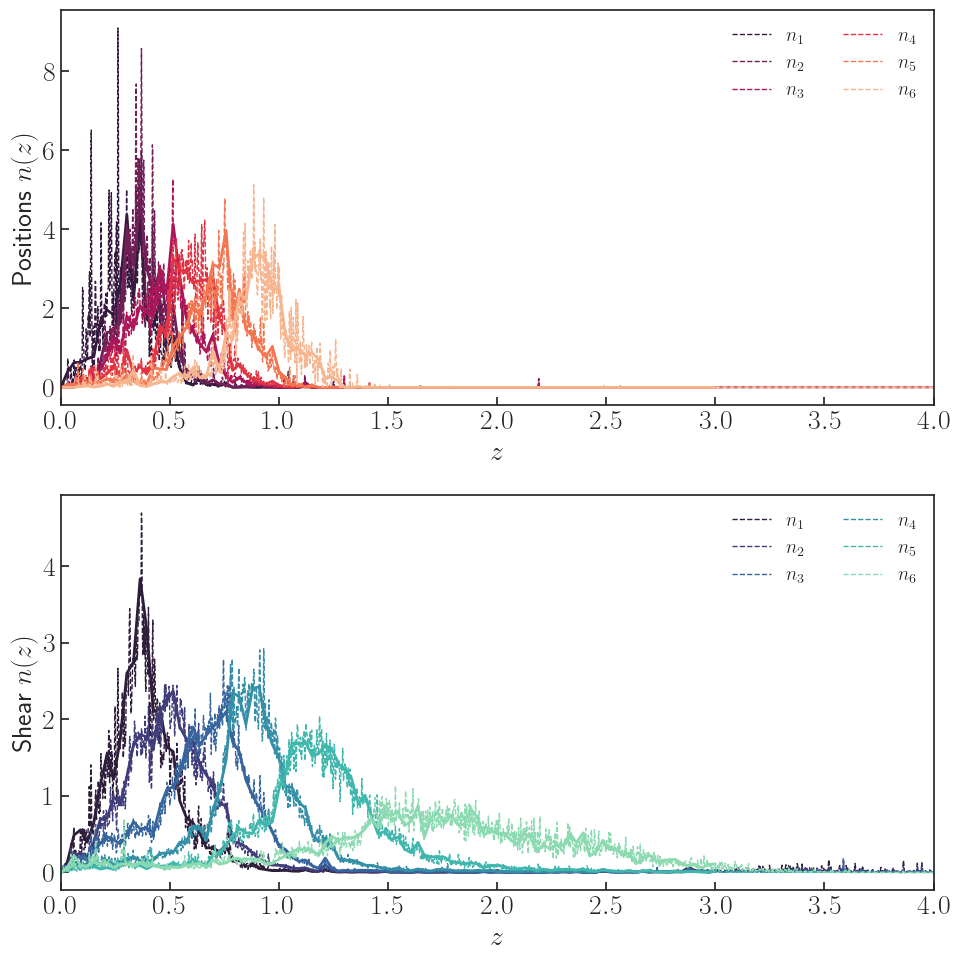

In [10]:
# Function to normalize dndz
def normalize_dndz(nz_example, z_nz):
    normalized = {}
    for key in nz_example:
        normalized[key] = nz_example[key] / integrate.trapezoid(nz_example[key], z_nz)
    return normalized

# Normalize both dndz_pos and dndz_she
dndz_pos_norm_new = normalize_dndz(nz_l, z_nz_l)
dndz_she_norm_new = normalize_dndz(nz_s, z_nz_s)

# Function to resample the normalized dndz
def resample_dndz(nz_example, z_nz, myz):
    my_dndz = np.vstack(list(nz_example.values()))
    my_dndz_norm = np.zeros([len(nz_example), len(myz)])
    for i in range(len(nz_example)):
        my_dndz_norm[i, :] = np.interp(myz, z_nz, my_dndz[i, :])
    return my_dndz_norm

# Resampling the normalized dndz with 100 values
my_dndz_pos_norm_new = resample_dndz(dndz_pos_norm_new, z_nz_l, zs)
my_dndz_she_norm_new = resample_dndz(dndz_she_norm_new, z_nz_s, zs)

# Plotting dndz
fig, axs = plt.subplots(2, 1, figsize=(10, 10))

# Customize tick parameters for both axes
for ax in axs.flatten():
    ax.tick_params(axis='both', which='both', direction='in')

# Plot positions n(z)
for i, (key, color) in enumerate(zip(dndz_pos_norm_new.keys(), sns.color_palette("rocket", len(dndz_pos_norm_new)))):
    axs[0].plot(z_nz_l, dndz_pos_norm_new[key], label=f'$n_{{{i+1}}}$', linewidth=1, color=color, linestyle='--')
    axs[0].plot(zs, my_dndz_pos_norm_new[i, :], linewidth=2, color=color, linestyle='-')

# Plot shear n(z)
for j, (key, color) in enumerate(zip(dndz_she_norm_new.keys(), sns.color_palette("mako", len(dndz_she_norm_new)))):
    axs[1].plot(z_nz_s, dndz_she_norm_new[key], label=f'$n_{{{j+1}}}$', linewidth=1, color=color, linestyle='--')
    axs[1].plot(zs, my_dndz_she_norm_new[j, :], linewidth=2, color=color, linestyle='-')

# Set labels and legends
axs[0].set_xlabel(r'$z$')
axs[0].set_ylabel(r'Positions $n(z)$')
axs[0].set_xlim(0, 4)
axs[0].legend(frameon=False, ncol=2)

axs[1].set_xlabel(r'$z$')
axs[1].set_ylabel(r'Shear $n(z)$')
axs[1].set_xlim(0, 4)
axs[1].legend(frameon=False, ncol=2)

plt.tight_layout()
plt.show()


In [11]:
ell_cell = mixmats[('SHE', 'SHE', 1, 1)].ell
ell_cell

array([  10.52272727,   13.04938272,   16.04040404,   19.03418803,
         22.55434783,   27.07272727,   32.06153846,   38.1038961 ,
         45.61413043,   54.65      ,   65.68055556,   78.17834395,
         93.25668449,  111.796875  ,  133.32958801,  159.43887147,
        191.0039267 ,  228.08442982,  272.20557598,  325.36230769,
        389.02102102,  464.70743534,  555.47279832,  664.25      ,
        793.56218434,  947.98616984, 1132.97803332, 1354.05286208,
       1618.77982456, 1935.07847708, 2312.57206329, 2763.22897394])

In [12]:
len(cls_wl["SHE", "SHE",i, j][0, 1][2:])

30

In [13]:
# Extract weak lensing covariance submatrix
# Shape: (n_tomographic_pairs * n_ell_bins, n_tomographic_pairs * n_ell_bins)
# For 6 bins: (21+21)*32 = 1344 elements (EE + BB correlations)
cov_WL = full_cov[:(21+21)*32, :(21+21)*32]

In [14]:
diag_error = np.sqrt(np.diag(cov_WL))
diag_error

array([4.03849499e-11, 3.62497497e-11, 3.27985595e-11, ...,
       5.17545476e-13, 4.34557064e-13, 3.65367337e-13])

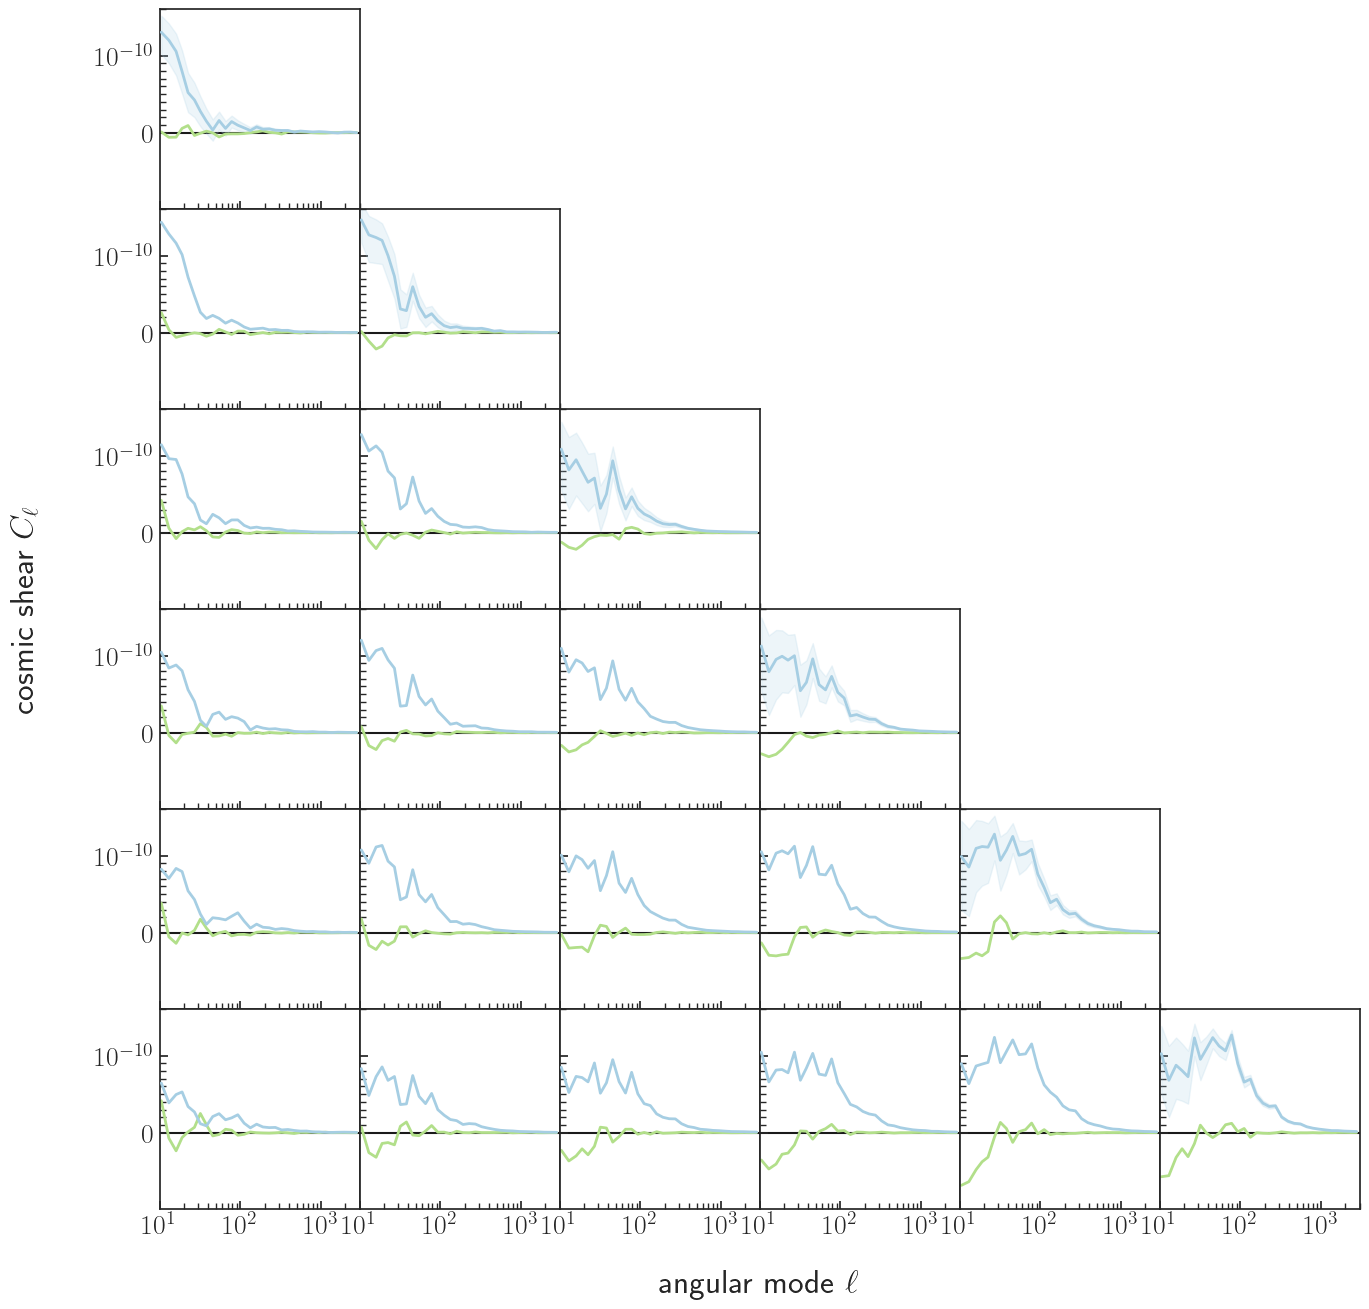

In [15]:
fig, ax = plt.subplots(6, 6, figsize=(12, 12), sharex=True, sharey=True)
for i in range(1, 7):
    for j in range(1, i):
        ax[j - 1, i - 1].axis("off")
    for j in range(i, 7):
        ax[j - 1, i - 1].plot(
            ell_cell[:],
            cls_wl["SHE", "SHE",i, j][0, 0][:],
            c="C0",
            lw=2,
            zorder=3.0,
            #alpha=0.4,
        )
        if i==j:
            ax[j - 1, i - 1].fill_between(
                ell_cell[:],
                cls_wl["SHE", "SHE",i, j][0, 0][:]-diag_error[i*32:(i+1)*32],
                cls_wl["SHE", "SHE",i, j][0, 0][:]+diag_error[i*32:(i+1)*32],
                color="C0",
                alpha=0.2,

            )
        ax[j - 1, i - 1].plot(
            ell_cell[:],
             cls_wl["SHE", "SHE",i, j][0, 1][:],
            c="C2",
            lw=2,
            zorder=1.0,
            #alpha=0.4,
        )
        ax[j - 1, i - 1].axhline(0.0, c="k", lw=1.5, zorder=-1)
        ax[j - 1, i - 1].tick_params(axis="both", which="both", direction="in")

ax[0, 0].set_xscale("log")
ax[0, 0].set_xlim(10, 3000)
ax[0, 0].xaxis.get_major_locator().set_params(numticks=99)
ax[0, 0].xaxis.get_minor_locator().set_params(
    numticks=99, subs=np.arange(0.1, 1.0, 0.1)
)
ax[0, 0].set_yscale(
    "symlog", linthresh=1e-10, linscale=0.45, subs=np.arange(0.1, 1.0, 0.1)
)
ax[0, 0].set_ylim(-1e-10, 2e-10)

fig.subplots_adjust(left=0.0, bottom=0.0, right=1.0, top=1.0, wspace=0.0, hspace=0.0)

fig.supxlabel("angular mode $\\ell$", y=-0.05, va="top")
fig.supylabel("cosmic shear $C_\\ell$", x=-0.1, ha="right")

plt.show()

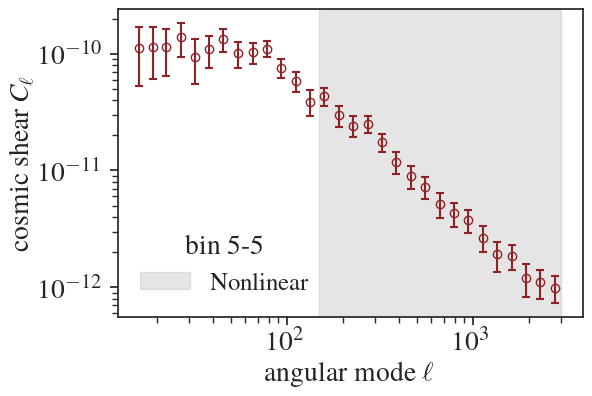

In [16]:
from matplotlib import rc
rc('text', usetex=True)
rc('font',**{'family':'serif','serif':['Times']})

plt.rc('mathtext', fontset='stix')
plt.rc('xtick',labelsize=20)
plt.rc('ytick',labelsize=20)
plt.rc('font',size=20)
plt.rc('axes', titlesize=25)
plt.rc('axes', labelsize=20)
plt.rc('lines', linewidth=3)
plt.rc('lines', markersize=6)
plt.rc('legend', fontsize=18)
# Create two-panel figure with power spectra and ratios
colors = [#'#902124', '#C2858C', 
    '#4D0011', '#709BEB', '#C2858C', 
           ]
i = 5
fig, ax = plt.subplots(figsize=(6, 4))
ax.errorbar(
                ell_cell[2:],
                cls_wl["SHE", "SHE",i, i][0, 0][2:],
                yerr=diag_error[i*32+2:(i+1)*32],
                color='#902124',
                marker='o',
                markerfacecolor='none',
                markeredgecolor='#902124',
                linestyle='none',
                capsize=3,
                capthick=1.5,
                elinewidth=1.5,
            )
ax.set_xscale('log')
ax.set_yscale('log')
#ax.set_xlim(0.01, 2.)
#ax.set_ylim(0.45, 1.)

ax.set_xlabel("angular mode $\\ell$")
ax.set_ylabel("cosmic shear $C_\\ell$")
ax.axvspan(150, 3000, color='gray', alpha=0.2, label='Nonlinear')
ax.legend(loc='lower left', frameon=False, ncol=2, title='bin 5-5', title_fontsize=20)

In [23]:
# The arguments of the Background functions follow the cosmology.API
background = CAMBBackground(H0=72.4, 
                            Omega_cdm0=0.25, 
                            Omega_b0=0.05, 
                            w0=-1, 
                            wa=0, 
                            Omega_k0 = 0.0, 
                            ns = 0.97, 
                            As = 1.6e-9,#0.9e-9,#1.6e-9,
                            mnu = 0.06,
                            gamma_MG = 0.545)
linear_perturbations_emu = HMemuLinearPerturbations(background, zs)
nonlinear_perturbations_emu = HMemuNonLinearPerturbations(background, linear_perturbations_emu, zs, log10TAGN=7.8)

In [24]:
# Select the perturbations object you want to use
perturbations = nonlinear_perturbations_emu

tracer_she = ShearTracer(perturbations=perturbations, 
                             dndz=my_dndz_she_norm,#my_dndz_she_norm_new,
                             z = zs,
                             nuisance_params={'AIA': -1.5, 'CIA': 0.0134, 
                                                'EtaIA':0., #-0.41,
                                              'multiplicative_bias_1': 0.001, 'multiplicative_bias_2': 0.008,
                                              'multiplicative_bias_3': -0.005, 'multiplicative_bias_4': 0.026,
                                              'multiplicative_bias_5': 0.037, 'multiplicative_bias_6': -0.045,
                                              'dz_shear_1': 0.0001, 'dz_shear_2': 0.0001,
                                              'dz_shear_3': 0.0001, 'dz_shear_4': 0.0001,
                                              'dz_shear_5': 0.0001, 'dz_shear_6': 0.0001})

In [25]:
nl = 100
ells = np.logspace(1., np.log10(3000), nl)
twopoint_sheshe = AngularTwoPoint(tracer_she, tracer_she)
cells_SS = twopoint_sheshe.get_pseudo_Cl(nl, perturbations.k,mixmats)

In [20]:
nl = 100
ells = np.logspace(1., np.log10(3000), nl)
twopoint_sheshe = AngularTwoPoint(tracer_she, tracer_she)
cells_SS_low = twopoint_sheshe.get_pseudo_Cl(nl, perturbations.k,mixmats)

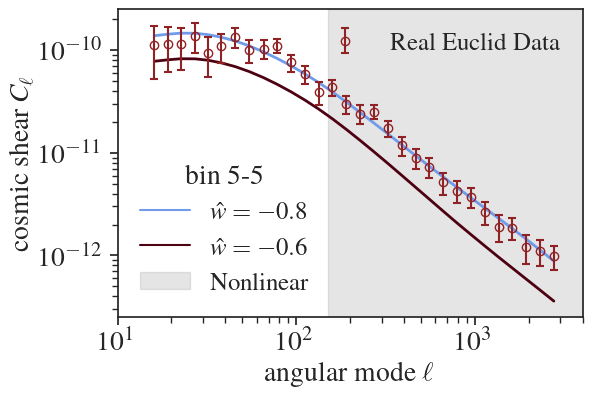

In [26]:
from matplotlib import rc
rc('text', usetex=True)
rc('font',**{'family':'serif','serif':['Times']})

plt.rc('mathtext', fontset='stix')
plt.rc('xtick',labelsize=20)
plt.rc('ytick',labelsize=20)
plt.rc('font',size=20)
plt.rc('axes', titlesize=25)
plt.rc('axes', labelsize=20)
plt.rc('lines', linewidth=3)
plt.rc('lines', markersize=6)
plt.rc('legend', fontsize=18)
# Create two-panel figure with power spectra and ratios
colors = [#'#902124', '#C2858C', 
    '#4D0011', '#709BEB', '#C2858C', 
           ]
i = 5
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(ell_cell[2:], cells_SS["SHE", "SHE",i, j][0,0,2:], color=colors[1], lw=2)#, zorder=3.0)
ax.plot(ell_cell[2:], cells_SS_low["SHE", "SHE",i, j][0,0,2:], color=colors[0], lw=2)#, zorder=3.0)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(10, 4000.)
ax.set_ylim(2.5e-13, 2.5e-10)

ax.set_xlabel("angular mode $\\ell$")
ax.set_ylabel("cosmic shear $C_\\ell$")
ax.axhline(1e-14, color=colors[1], linestyle='-', linewidth=1.5, label='$\hat{w}=-0.8$')
ax.axhline(1e-14, color=colors[0], linestyle='-', linewidth=1.5, label='$\hat{w}=-0.6$')
ax.axvspan(150, 4000, color='gray', alpha=0.2, label='Nonlinear')
data_handle = ax.errorbar(
                ell_cell[2:],
                cls_wl["SHE", "SHE",i, i][0, 0][2:],
                yerr=diag_error[i*32+2:(i+1)*32],
                color='#902124',
                marker='o',
                markerfacecolor='none',
                markeredgecolor='#902124',
                linestyle='none',
                capsize=3,
                capthick=1.5,
                elinewidth=1.5,
                label='Data'
            )
# Get all handles and labels
handles, labels = ax.get_legend_handles_labels()
# Separate "Data" from other labels
main_handles = []
main_labels = []
data_handle_legend = None
for handle, label in zip(handles, labels):
    if label == 'Data':
        data_handle_legend = handle
    else:
        main_handles.append(handle)
        main_labels.append(label)
# Create main legend first and add it as an artist (so it persists)
main_legend = ax.legend(main_handles, main_labels, loc='lower left', frameon=False, ncol=1, title='bin 5-5', title_fontsize=20)
ax.add_artist(main_legend)
# Create separate legend for Data in upper right corner
if data_handle_legend is not None:
    ax.legend([data_handle_legend], ['Real Euclid Data'], loc='upper right', frameon=False)
plt.savefig('photo_rr2.pdf', dpi=300, bbox_inches='tight')    

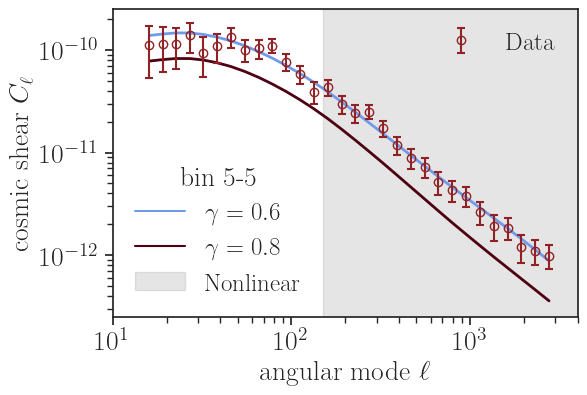

In [29]:
from matplotlib import rc
rc('text', usetex=True)
rc('font',**{'family':'serif','serif':['Computer Modern Roman']})

plt.rc('mathtext', fontset='stix')
plt.rc('xtick',labelsize=20)
plt.rc('ytick',labelsize=20)
plt.rc('font',size=20)
plt.rc('axes', titlesize=25)
plt.rc('axes', labelsize=20)
plt.rc('lines', linewidth=3)
plt.rc('lines', markersize=6)
plt.rc('legend', fontsize=18)
# Create two-panel figure with power spectra and ratios
colors = [#'#902124', '#C2858C', 
    '#4D0011', '#709BEB', '#C2858C', 
           ]
i = 5
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(ell_cell[2:], cells_SS["SHE", "SHE",i, j][0,0,2:], color=colors[1], lw=2)#, zorder=3.0)
ax.plot(ell_cell[2:], cells_SS_low["SHE", "SHE",i, j][0,0,2:], color=colors[0], lw=2)#, zorder=3.0)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(10, 4000.)
ax.set_ylim(2.5e-13, 2.5e-10)

ax.set_xlabel("angular mode $\\ell$")
ax.set_ylabel("cosmic shear $C_\\ell$")
ax.axhline(1e-14, color=colors[1], linestyle='-', linewidth=1.5, label='$\gamma=0.6$')
ax.axhline(1e-14, color=colors[0], linestyle='-', linewidth=1.5, label='$\gamma=0.8$')
ax.axvspan(150, 4000, color='gray', alpha=0.2, label='Nonlinear')
data_handle = ax.errorbar(
                ell_cell[2:],
                cls_wl["SHE", "SHE",i, i][0, 0][2:],
                yerr=diag_error[i*32+2:(i+1)*32],
                color='#902124',
                marker='o',
                markerfacecolor='none',
                markeredgecolor='#902124',
                linestyle='none',
                capsize=3,
                capthick=1.5,
                elinewidth=1.5,
                label='Data'
            )
# Get all handles and labels
handles, labels = ax.get_legend_handles_labels()
# Separate "Data" from other labels
main_handles = []
main_labels = []
data_handle_legend = None
for handle, label in zip(handles, labels):
    if label == 'Data':
        data_handle_legend = handle
    else:
        main_handles.append(handle)
        main_labels.append(label)
# Create main legend first and add it as an artist (so it persists)
main_legend = ax.legend(main_handles, main_labels, loc='lower left', frameon=False, ncol=1, title='bin 5-5', title_fontsize=20)
ax.add_artist(main_legend)
# Create separate legend for Data in upper right corner
if data_handle_legend is not None:
    ax.legend([data_handle_legend], ['Data'], loc='upper right', frameon=False)
plt.savefig('photo_rr2_fakegamma.pdf', dpi=300, bbox_inches='tight')  